# Face Generation: StyleGAN2-ADA transfer (FFHQ-256 → CelebV-HQ) in RTX 5090

**구현 방법** 얼굴 FID의 SOTA인 StyleGAN2를 사용. NVIDIA의 **FFHQ-256 pretrained**를 CelebV-HQ 프레임으로 **transfer-learning(ADA)**

흐름: ① CelebV-HQ 프레임 추출·정제 → ② StyleGAN 데이터셋(zip) 생성 → ③ `--resume=ffhq256`로 transfer 학습 → ④ 1,000장 생성 → ⑤ 로컬 FID/IS/KID → ⑥ zip 제출.

**Blackwell**: StyleGAN2-ADA의 커스텀 op 중 torch 2.x에서 깨지는 `conv2d_gradfix`/`grid_sample_gradfix`는 비활성(native fallback), numpy 2에서 제거된 `np.float`/`np.int` 별칭은 패치, `bias_act`/`upfirdn2d`는 nvcc로 컴파일.

> 환경: Colab(로컬 런타임) + RTX 5090. **CUDA 12.8+ 툴킷(nvcc) 필요**(커스텀 op 컴파일용).

## 0. 환경 점검 — torch(Blackwell) + nvcc

In [ ]:
!nvidia-smi -L
import subprocess
def torch_ok():
    try:
        import torch
        if not torch.cuda.is_available(): return False, 'CUDA 불가'
        cap = torch.cuda.get_device_capability(0)
        _ = (torch.randn(64,64,device='cuda') @ torch.randn(64,64,device='cuda')).sum().item()
        return True, f'torch {torch.__version__}, sm_{cap[0]}{cap[1]}'
    except Exception as e:
        return False, str(e)
ok, msg = torch_ok(); print('torch:', ok, '|', msg)
if not ok:
    raise SystemExit
# nvcc (커스텀 op 컴파일용)
print(subprocess.run(['bash','-lc','nvcc --version || echo "nvcc 없음 — CUDA toolkit 설치 필요"'],
                     capture_output=True, text=True).stdout)


GPU 0: NVIDIA GeForce RTX 5070 Ti (UUID: GPU-00eca02c-d6dd-3434-f60a-124f60505e27)
torch: True | torch 2.10.0+cu128, sm_120
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0



## 1. StyleGAN2-ADA 클론 + 의존성 + Blackwell 패치

In [ ]:
import os, subprocess
WORK = '/content/sg'; os.makedirs(WORK, exist_ok=True)
REPO_DIR = f'{WORK}/stylegan2-ada-pytorch'

if not os.path.isdir(REPO_DIR):
    !git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git {REPO_DIR}

## 의존성 (torch/numpy는 안 건드림)
!pip -q install ninja click requests tqdm scipy psutil imageio imageio-ffmpeg
!pip -q install av huggingface_hub torch-fidelity
!pip -q install pyspng 2>/dev/null || echo '(pyspng optional)'

## Blackwell / torch2.x / numpy2 호환 패치
# (a) torch 2.x에서 깨지는 gradfix 비활성 → native 연산 fallback
!sed -i 's/^enabled = True/enabled = False/' {REPO_DIR}/torch_utils/ops/conv2d_gradfix.py
!sed -i 's/^enabled = True/enabled = False/' {REPO_DIR}/torch_utils/ops/grid_sample_gradfix.py
# (b) numpy 2에서 제거된 별칭 패치 (단어 경계로 np.float32 등은 보호)
!cd {REPO_DIR} && find . -name '*.py' -print0 | xargs -0 sed -i -E 's/\bnp\.float\b/np.float64/g; s/\bnp\.int\b/np.int64/g; s/\bnp\.bool\b/np.bool_/g; s/\bnp\.object\b/np.object_/g; s/\bnp\.complex\b/np.complex128/g'
print('patched gradfix(enabled=False) + numpy2 aliases')
print('conv2d_gradfix:', subprocess.run(['bash','-lc',f'grep -m1 \"^enabled\" {REPO_DIR}/torch_utils/ops/conv2d_gradfix.py'],capture_output=True,text=True).stdout.strip())


Cloning into '/content/sg/stylegan2-ada-pytorch'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 131 (delta 0), reused 0 (delta 0), pack-reused 129 (from 2)
Receiving objects: 100% (131/131), 1.13 MiB | 3.40 MiB/s, done.
Resolving deltas: 100% (57/57), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 5.8 MB/s eta 0:00:00
patched gradfix(enabled=False) + numpy2 aliases
conv2d_gradfix: enabled = False                     # Enable the custom op by setting this to true.


## 2. 전역 설정

In [ ]:
import os, torch
PROJECT_DIR = '/content/face_contest'
device = torch.device('cuda')
GLOBAL_SEED = 42

IMG_DIR    = f'{PROJECT_DIR}/sg_train_imgs'   # 학습 이미지(정제된 256 프레임)
REF_EVAL_DIR = f'{PROJECT_DIR}/refs/eval'     # 로컬 FID용 held-out CelebV-HQ
DATA_ZIP   = f'{PROJECT_DIR}/celebvhq256.zip' # StyleGAN 데이터셋
OUTDIR     = f'{PROJECT_DIR}/training-runs'   # 학습 스냅샷
SAMPLES_DIR= f'{PROJECT_DIR}/samples_raw'
for d in (IMG_DIR, REF_EVAL_DIR, OUTDIR, SAMPLES_DIR):
    os.makedirs(d, exist_ok=True)
print('device =', torch.cuda.get_device_name(0))


device = NVIDIA GeForce RTX 5070 Ti


## 3. CelebV-HQ 프레임 추출 + 정제

`videos.tar` 순차 스트리밍 → 센터크롭 256 + 선명도 필터. 학습용(IMG_DIR) + 평가용(REF_EVAL_DIR) 분리.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


extract:   0%|          | 0/18000 [00:00<?, ?it/s]

sharpness:   0%|          | 0/18000 [00:00<?, ?it/s]

train=12300, eval=3000


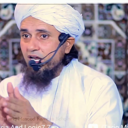

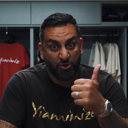

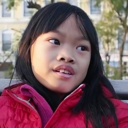

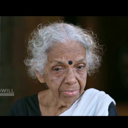

In [ ]:
import io, glob, tarfile
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
import imageio.v3 as iio
from huggingface_hub import HfFileSystem

TARGET_TRAIN, TARGET_EVAL = 15000, 3000
FRAMES_PER_CLIP, STRIDE, OUT = 4, 20, 256
SHARP_KEEP_FRAC = 0.85
TAR = 'datasets/SwayStar123/CelebV-HQ/videos.tar'

def cnt(d): return len([f for f in os.listdir(d) if f.lower().endswith(('.png','.jpg','.jpeg'))])
def to256(arr):
    im = Image.fromarray(arr).convert('RGB'); w,h=im.size; s=min(w,h)
    im = im.crop(((w-s)//2,(h-s)//2,(w+s)//2,(h+s)//2))
    return im.resize((OUT,OUT), Image.LANCZOS)
def frames(vb,n,st,mx=4000):
    o=[]
    try:
        for i,fr in enumerate(iio.imiter(io.BytesIO(vb), plugin='pyav')):
            if i%st==0:
                o.append(np.asarray(fr))
                if len(o)>=n: break
            if i>mx: break
    except Exception: pass
    return o

raw = f'{PROJECT_DIR}/_raw_tmp'; os.makedirs(raw, exist_ok=True)
need = TARGET_TRAIN + TARGET_EVAL - cnt(raw) - cnt(REF_EVAL_DIR)
if cnt(raw) < TARGET_TRAIN + TARGET_EVAL:
    fs = HfFileSystem(); fobj = fs.open(TAR,'rb'); tar = tarfile.open(fileobj=fobj, mode='r|')
    sr = cnt(raw); pbar = tqdm(total=TARGET_TRAIN+TARGET_EVAL-sr, desc='extract')
    for m in tar:
        if sr >= TARGET_TRAIN+TARGET_EVAL: break
        if (not m.isfile()) or (not m.name.lower().endswith('.mp4')): continue
        try: vb = tar.extractfile(m).read()
        except Exception: continue
        for fr in frames(vb, FRAMES_PER_CLIP, STRIDE):
            try: to256(fr).save(f'{raw}/r_{sr:06d}.png'); sr+=1; pbar.update(1)
            except Exception: pass
            if sr >= TARGET_TRAIN+TARGET_EVAL: break
    pbar.close(); tar.close(); fobj.close()

# 선명도 필터 후 train/eval 분배
def sharp(p):
    g = np.asarray(Image.open(p).convert('RGB'), np.float32).mean(2)
    lap = (-4*g[1:-1,1:-1]+g[:-2,1:-1]+g[2:,1:-1]+g[1:-1,:-2]+g[1:-1,2:])
    return float(lap.var())
allp = sorted(glob.glob(f'{raw}/*.png'))
scored = sorted(((p, sharp(p)) for p in tqdm(allp, desc='sharpness')), key=lambda x:-x[1])
keep = [p for p,_ in scored[:int(len(scored)*SHARP_KEEP_FRAC)]]
import shutil
for f in glob.glob(f'{IMG_DIR}/*.png'): os.remove(f)
for f in glob.glob(f'{REF_EVAL_DIR}/*.png'): os.remove(f)
for i,p in enumerate(keep):
    dst = REF_EVAL_DIR if i < TARGET_EVAL else IMG_DIR
    shutil.copy(p, f'{dst}/f_{i:06d}.png')
print(f'train={cnt(IMG_DIR)}, eval={cnt(REF_EVAL_DIR)}')
assert cnt(IMG_DIR) >= 2000
from IPython.display import display
for p in sorted(glob.glob(f'{IMG_DIR}/*.png'))[:4]: display(Image.open(p).resize((128,128)))


## 4. StyleGAN 데이터셋(zip) 생성

In [ ]:
import os
if os.path.exists(DATA_ZIP): os.remove(DATA_ZIP)
!cd {REPO_DIR} && python dataset_tool.py --source={IMG_DIR} --dest={DATA_ZIP} --width=256 --height=256
import zipfile
with zipfile.ZipFile(DATA_ZIP) as z: print('zip entries:', len(z.namelist()))


  0% 0/12300 [00:00<?, ?it/s]/content/sg/stylegan2-ada-pytorch/dataset_tool.py:429: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = PIL.Image.fromarray(img, { 1: 'L', 3: 'RGB' }[channels])
100% 12300/12300 [00:36<00:00, 338.39it/s]
zip entries: 12301


## 5. Transfer 학습 (FFHQ-256 → CelebV-HQ)

In [ ]:
!sed -i 's/super().__init__(dataset)/super().__init__()/' {REPO_DIR}/torch_utils/misc.py
print('InfiniteSampler 패치 완료')

InfiniteSampler 패치 완료


In [ ]:
# 커스텀 op을 ref로 강제 → upfirdn2d 컴파일 실패/반복 제거
!sed -i "s/impl='cuda'/impl='ref'/g" {REPO_DIR}/torch_utils/ops/upfirdn2d.py {REPO_DIR}/torch_utils/ops/bias_act.py
print('forced ref impl (컴파일 불필요, 다소 느리지만 안정적)')

forced ref impl (컴파일 불필요, 다소 느리지만 안정적)


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
import os
os.environ['TORCH_CUDA_ARCH_LIST'] = '12.0'
KIMG = 300
!cd {REPO_DIR} && python train.py \
  --outdir={OUTDIR} --data={DATA_ZIP} --gpus=1 --cfg=paper256 --workers=1 \
  --resume=ffhq256 --mirror=1 --aug=noaug --snap=4 --metrics=none --kimg={KIMG}
print('\n학습 종료(또는 중단). 스냅샷 목록:')
import glob
for p in sorted(glob.glob(f'{OUTDIR}/*/network-snapshot-*.pkl')): print(' ', p)

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
/content/sg/stylegan2-ada-pytorch/torch_utils/ops/conv2d_gradfix.py:55: UserWarning: conv2d_gradfix not supported on PyTorch 2.10.0+cu128. Falling back to torch.nn.functional.conv2d().
  warnings.warn(f'conv2d_gradfix not supported on PyTorch {torch.__version__}. Falling back to torch.nn.functional.conv2d().')
/content/sg/stylegan2-ada-pytorch/torch_utils/ops/conv2d_gradfix.py:55: UserWarning: conv2d_gradfix not supported on PyTorch 2.10.0+cu128. Falling back to torch.nn.functional.conv2d().
  warnings.warn(f'conv2d_gradfix not supported on PyTorch {torch.__version__}. Falling back to torch.nn.functional.conv2d().')
/content/sg/stylegan2-ada-pytorch/torch_utils/ops/conv2d_gradfix.py:55: UserWarning: conv2d_gradfix not supported on PyTorch 2.10.0+cu128. Falling back to torch.nn.functional.conv2d().
  warnings.warn(f'conv2d_gradfix not supported on PyTorch {torch.__version__}. Falling back to torch.nn.functional.conv2d().')
/content/sg/stylegan2-ada-py

## 6. 1,000장 생성 (최신 스냅샷)

using /content/face_contest/training-runs/00004/network-snapshot-000300.pkl
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/sg/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/sg/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/sg/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/importlib/__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  F

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/sg/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/sg/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/sg/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/importlib/__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  F

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


...

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/sg/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/sg/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/sg/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/importlib/__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  F

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/sg/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/sg/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/sg/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/importlib/__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  F

생성: 1000


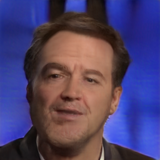

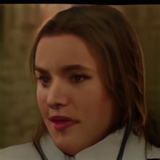

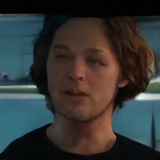

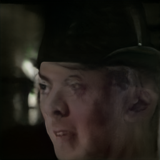

In [ ]:
import sys, glob, numpy as np, torch, PIL.Image
sys.path.insert(0, REPO_DIR)
import dnnlib, legacy

snaps = sorted(glob.glob(f'{OUTDIR}/*/network-snapshot-*.pkl'))
assert snaps, '스냅샷 없음 — 학습 셀을 먼저 실행'
NETWORK_PKL = snaps[-1]    # 최신 스냅샷
PSI = 1.0
SEED = 12345
N, B = 1000, 25
print('using', NETWORK_PKL)

with dnnlib.util.open_url(NETWORK_PKL) as f:
    G = legacy.load_network_pkl(f)['G_ema'].to(device).eval()

import os
for f in glob.glob(f'{SAMPLES_DIR}/*.png'): os.remove(f)
idx = 0
with torch.no_grad():
    for s in range(0, N, B):
        bs = min(B, N-s)
        z = torch.from_numpy(np.stack([np.random.RandomState(SEED+s+j).randn(G.z_dim)
                                       for j in range(bs)])).to(device).float()
        c = torch.zeros([bs, G.c_dim], device=device)
        img = G(z, c, truncation_psi=PSI, noise_mode='const')
        img = (img.permute(0,2,3,1)*127.5+128).clamp(0,255).to(torch.uint8).cpu().numpy()
        for j in range(bs):
            PIL.Image.fromarray(img[j],'RGB').save(f'{SAMPLES_DIR}/img_{idx:04d}.png'); idx+=1
print('생성:', idx)
from IPython.display import display
for p in sorted(glob.glob(f'{SAMPLES_DIR}/*.png'))[:4]: display(PIL.Image.open(p).resize((160,160)))


## 7. `submission.zip` 패키징

In [ ]:
import os, zipfile, glob, json
from PIL import Image
from tqdm.auto import tqdm
SUB_DIR=f'{PROJECT_DIR}/submission_imgs'; SUB_ZIP=f'{PROJECT_DIR}/submission.zip'
os.makedirs(SUB_DIR, exist_ok=True)
for f in glob.glob(f'{SUB_DIR}/*.jpg'): os.remove(f)
for i in tqdm(range(1000), desc='to JPG'):
    Image.open(f'{SAMPLES_DIR}/img_{i:04d}.png').convert('RGB').save(
        f'{SUB_DIR}/img_{i:04d}.jpg','JPEG',quality=95,subsampling=0)
if os.path.exists(SUB_ZIP): os.remove(SUB_ZIP)
with zipfile.ZipFile(SUB_ZIP,'w',zipfile.ZIP_DEFLATED) as zf:
    for i in range(1000): zf.write(f'{SUB_DIR}/img_{i:04d}.jpg', arcname=f'img_{i:04d}.jpg')
size_mb=os.path.getsize(SUB_ZIP)/1e6
with zipfile.ZipFile(SUB_ZIP) as zf: names=zf.namelist()
assert len(names)==1000 and all('/' not in n for n in names) and size_mb<200
json.dump(dict(method='StyleGAN2-ADA transfer ffhq256→CelebV-HQ', cfg='paper256',
               network=NETWORK_PKL, truncation_psi=PSI, sample_seed=SEED),
          open(f'{PROJECT_DIR}/submission_meta.json','w'), indent=2, ensure_ascii=False)
print(f'{SUB_ZIP}: {size_mb:.1f} MB | {len(names)} files')


to JPG:   0%|          | 0/1000 [00:00<?, ?it/s]

/content/face_contest/submission.zip: 21.6 MB | 1000 files
